# 심층 신경망

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/rickiepark/hg-mldl/blob/master/7-2.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

In [2]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
# import tensorflow as tf

# tf.keras.utils.set_random_seed(42)
# tf.config.experimental.enable_op_determinism()

## 2개의 층

In [3]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [4]:
from sklearn.model_selection import train_test_split

# 이미지 데이터 (0~255) 범위 -> (0.~1.)
train_scaled = train_input / 255.0
#  이미지 2차원 -> 1차원
train_scaled = train_scaled.reshape(-1, 28*28)

# 훈련셋에서 20%를 검증셋으로 분할
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

## 은닉층(hidden layer)를 추가
## 이제 로지스틱 회귀와 구조가 달라졌다
## 은닉층을 추가한 인공 신경망을 심층 신경망이라고 한다
## 심층 신경망을 학습시키는 것을 ```딥러닝```이라고 한다
## 은닉층을 추가하면 신경망에 비선형성을 증가시켜서, 복잡한 문제를 해결할 수 있다
## 단, 은닉층이 깊어지면 학습이 잘 안되는 문제가 따라오므로, 실험을 통해서 최적의 hyperparameter 조합을 찾아야 한다

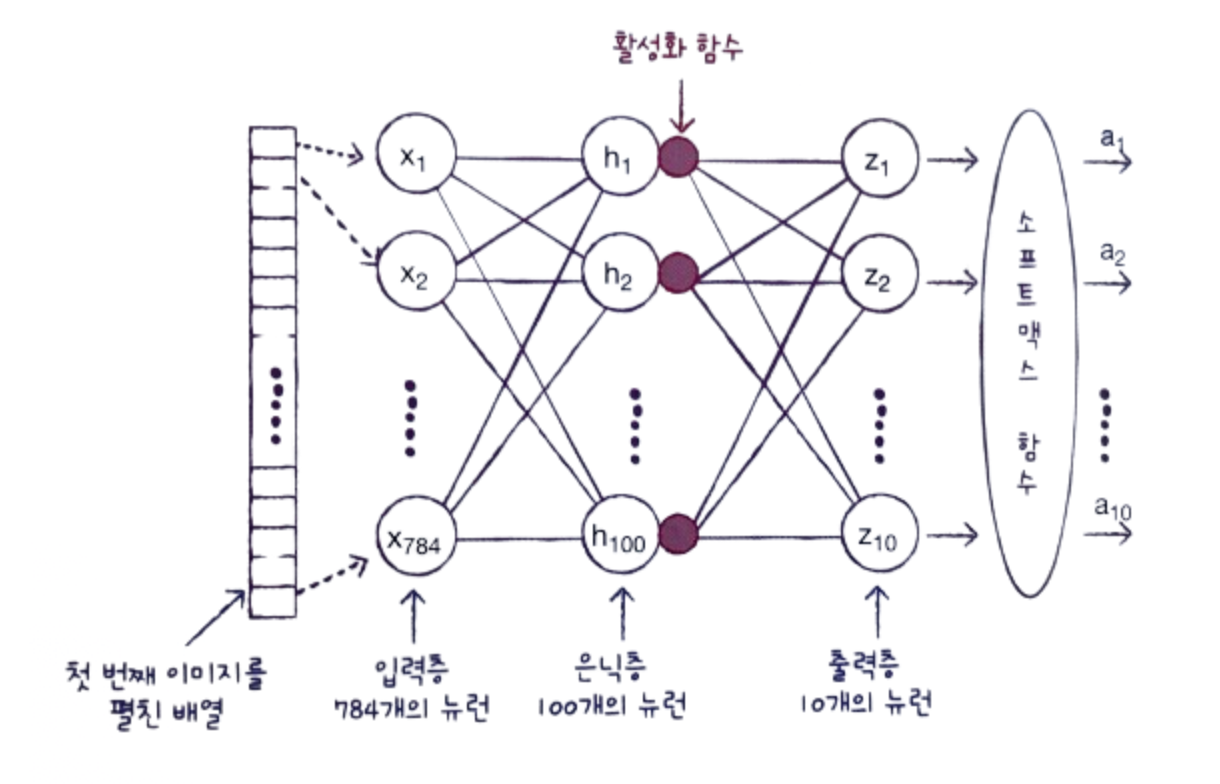

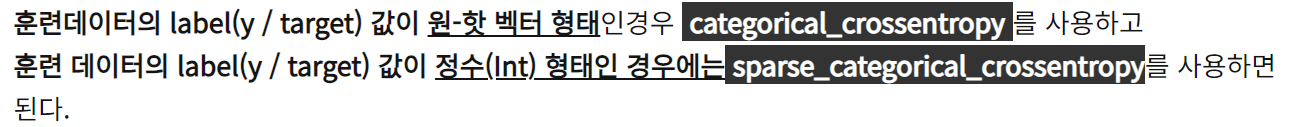

In [5]:
# 입력층(768) -> 각 노드당 I•w+b -> 신경망 출력(100) -> sigmoid -> 함수 통과 출력(100) -> 
# 은닉층(100) -> 각 노드당 I•w+b -> 신경망 출력(10) -> softmax -> 함수 통과 출력(10) -> 
# loss를 통해 정답 비교(sparse_categorical_crossentropy) 
# 오차역전파 알고리즘 : -> 비교값을 역으로 전달 -> w값이 출력에 미치는 영향(미분) -> w의 방향 결정 -> 조금씩 조정

# 각 계층 생성
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,))
dense2 = keras.layers.Dense(10, activation='softmax')

## 심층 신경망 만들기

In [6]:
# 각 계층을 순서대로 쌓아준다
model = keras.Sequential([dense1, dense2])

## 784(입력층 값 갯수) * 100(weight 갯수) + 100(bias 갯수) = 78500
## 100 * 10 + 10 = 1010

In [8]:
# 신경망 설계 정보 보기
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 100)               78500     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1010      
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


## 층을 추가하는 다른 방법

In [9]:
model = keras.Sequential([
    keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name='hidden'),
    keras.layers.Dense(10, activation='softmax', name='output')
], name='패션 MNIST 모델')

In [10]:
model.summary()

Model: "패션 MNIST 모델"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hidden (Dense)               (None, 100)               78500     
_________________________________________________________________
output (Dense)               (None, 10)                1010      
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [11]:
# 이렇게 할 수도 있다.
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(keras.layers.Dense(10, activation='softmax'))

In [12]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 100)               78500     
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1010      
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [14]:
# 모델에 손실함수(비용함수)를 더해서 모델 완성
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습
model.fit(train_scaled, train_target, epochs=10)

Epoch 1/10
1500/1500 [==============================] - 1s 868us/step - loss: 0.3216 - accuracy: 0.8840
Epoch 2/10
1500/1500 [==============================] - 1s 767us/step - loss: 0.3094 - accuracy: 0.8877
Epoch 3/10
1500/1500 [==============================] - 1s 840us/step - loss: 0.2997 - accuracy: 0.8912
Epoch 4/10
1500/1500 [==============================] - 1s 821us/step - loss: 0.2891 - accuracy: 0.8948
Epoch 5/10
1500/1500 [==============================] - 1s 791us/step - loss: 0.2821 - accuracy: 0.8977
Epoch 6/10
1500/1500 [==============================] - 1s 813us/step - loss: 0.2740 - accuracy: 0.8997
Epoch 7/10
1500/1500 [==============================] - 1s 863us/step - loss: 0.2665 - accuracy: 0.9032
Epoch 8/10
1500/1500 [==============================] - 1s 789us/step - loss: 0.2606 - accuracy: 0.9050
Epoch 9/10
1500/1500 [==============================] - 1s 806us/step - loss: 0.2546 - accuracy: 0.9074
Epoch 10/10
1500/1500 [==============================] - 1s 875u

## 렐루 활성화 함수

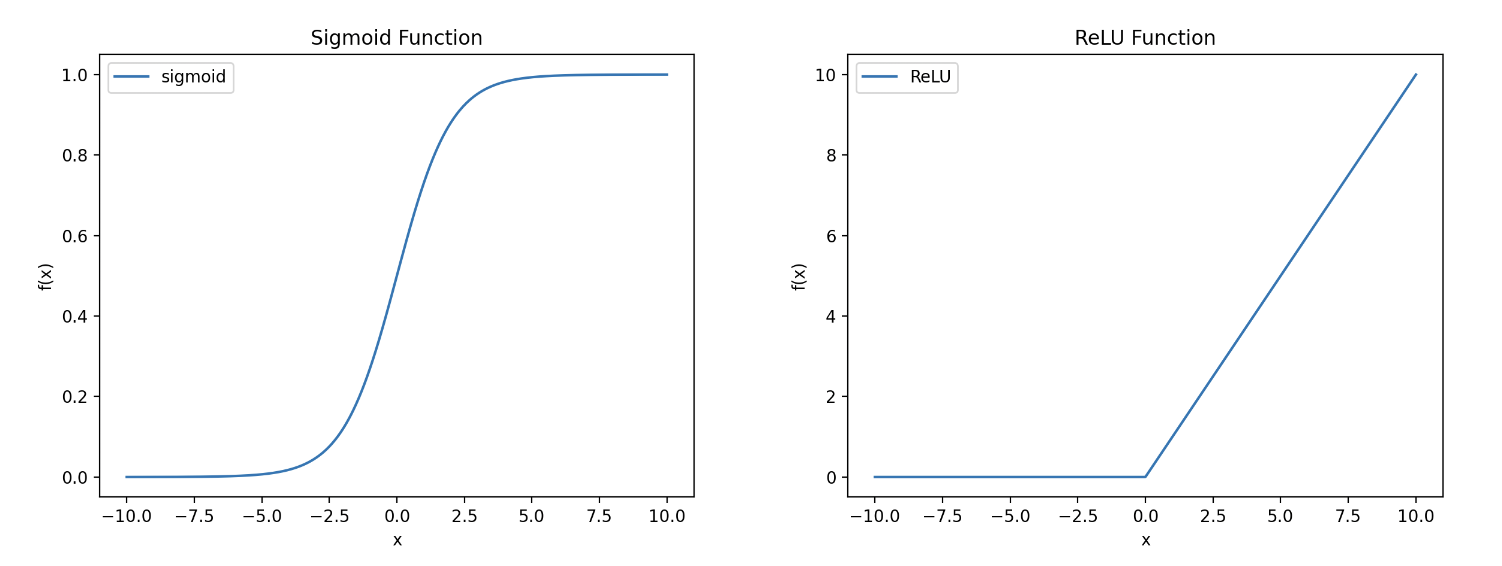

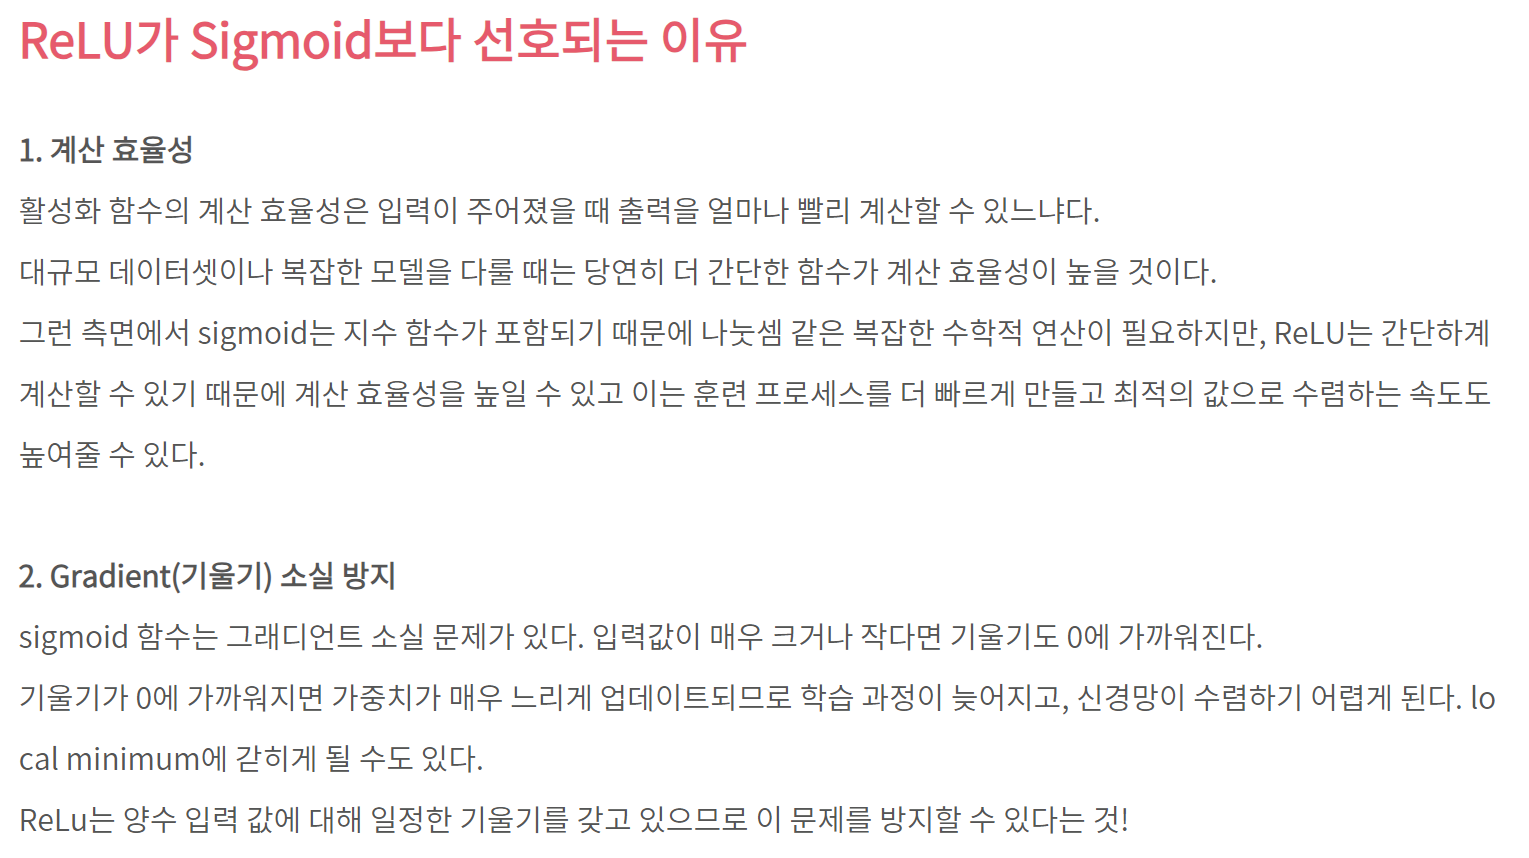

In [15]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))       # 좀 더 편리하게 (28, 28) -> (784)로 만들어준다
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [16]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 100)               78500     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [17]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [20]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_scaled, train_target, epochs=10)

Epoch 1/10
1500/1500 [==============================] - 1s 745us/step - loss: 0.3085 - accuracy: 0.8906
Epoch 2/10
1500/1500 [==============================] - 1s 845us/step - loss: 0.2983 - accuracy: 0.8940
Epoch 3/10
1500/1500 [==============================] - 1s 767us/step - loss: 0.2920 - accuracy: 0.8976
Epoch 4/10
1500/1500 [==============================] - 1s 786us/step - loss: 0.2840 - accuracy: 0.8997
Epoch 5/10
1500/1500 [==============================] - 1s 751us/step - loss: 0.2788 - accuracy: 0.9036
Epoch 6/10
1500/1500 [==============================] - 1s 837us/step - loss: 0.2726 - accuracy: 0.9031
Epoch 7/10
1500/1500 [==============================] - 1s 745us/step - loss: 0.2638 - accuracy: 0.9077
Epoch 8/10
1500/1500 [==============================] - 1s 792us/step - loss: 0.2592 - accuracy: 0.9108
Epoch 9/10
1500/1500 [==============================] - 1s 829us/step - loss: 0.2539 - accuracy: 0.9109
Epoch 10/10
1500/1500 [==============================] - 1s 782u

In [21]:
model.evaluate(val_scaled, val_target)

375/375 [==============================] - 0s 641us/step - loss: 0.4264 - accuracy: 0.8818


[0.4263760447502136, 0.8818333148956299]

## 옵티마이저

## 경사하강법 알고리즘을 사용할 때
## 이동폭(learning_rate), 속도 등 여러 가지 hyperparameter가 있다
## local minimum에 걸려 학습이 진행되지 않는 경우나
## global minimum을 지나치는 경우 등 여러 오류 상황을 해결해야 한다
## 그래서 다양한 경사하강법 알고리즘이 존재한다
## keras의 기본은 RMSProp이고
## 가장 많이 사용하는 것은 Adam 이다
## Adam의 A는 Adaptive로 상황에 따라 변경한다는 뜻이다

In [22]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [23]:
sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [24]:
sgd = keras.optimizers.SGD(learning_rate=0.1)

In [25]:
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

In [26]:
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [27]:
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [28]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [31]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_scaled, train_target, epochs=10)

Epoch 1/10
1500/1500 [==============================] - 1s 790us/step - loss: 0.2900 - accuracy: 0.8938
Epoch 2/10
1500/1500 [==============================] - 1s 890us/step - loss: 0.2761 - accuracy: 0.8988
Epoch 3/10
1500/1500 [==============================] - 1s 877us/step - loss: 0.2657 - accuracy: 0.9000
Epoch 4/10
1500/1500 [==============================] - 1s 789us/step - loss: 0.2568 - accuracy: 0.9044
Epoch 5/10
1500/1500 [==============================] - 1s 801us/step - loss: 0.2476 - accuracy: 0.9081
Epoch 6/10
1500/1500 [==============================] - 1s 855us/step - loss: 0.2388 - accuracy: 0.9106
Epoch 7/10
1500/1500 [==============================] - 1s 802us/step - loss: 0.2325 - accuracy: 0.9134
Epoch 8/10
1500/1500 [==============================] - 1s 765us/step - loss: 0.2262 - accuracy: 0.9157
Epoch 9/10
1500/1500 [==============================] - 1s 932us/step - loss: 0.2173 - accuracy: 0.9186
Epoch 10/10
1500/1500 [==============================] - 1s 813u

In [32]:
model.evaluate(val_scaled, val_target)

375/375 [==============================] - 0s 660us/step - loss: 0.3304 - accuracy: 0.8840


[0.3304034173488617, 0.8840000033378601]